<a href="https://colab.research.google.com/github/helgadenes/Computational_Physics_USFQ/blob/main/Unit_4/4_3_Fast_Fourier_Transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fast Fourier Transform (FFT)

- DFT is slow.


- FFT is an algorithm that computes the discrete Fourier transform (DFT) of a sequence, or its inverse (IDFT).


- FFT exploits symmetries of the DFT to output results in a fraction of the time:

$$X_k = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{kn/N}}}$$

we can calculate the

$$X_{k+N} = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{(k+N)n/N}}} = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{n}}\cdot e^{-i2\pi{kn/N}}}$$

Note that, $e^{-i2\pi{n}} = 1$, therefore, we have

$$X_{k+N} = \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{kn/N}}} = X_k$$

Thus, we can have:

$$X_{k+i\cdot N} = X_k, \text{ for any integer i}$$

This means that within the DFT, we have symmetries that we can use to reduce the computation.


- Fourier analysis converts a signal from its original domain (often time or space) to a representation in the (temporal or spatial) frequency domain and vice versa.


- The DFT is obtained by decomposing a sequence of values into components of different frequencies. Computing it directly from the definition is often too slow to be practical.

**References:**

https://en.wikipedia.org/wiki/Fast_Fourier_transform

https://pythonnumericalmethods.berkeley.edu/notebooks/chapter24.03-Fast-Fourier-Transform.html

## Example 1:

### FFT Decomposition of $x(n) = (0, 1, 2, 3)$:


### 1: Butterfly Operations (even and odd indexed elements)

We consider:

$$x(n) = (x(0), x(1), x(2), x(3)) = (0, 1, 2, 3)$$

We rearrange the input into even and odd indexed sequences:

$$x_e(n) = (x(0), x(2)) = (0, 2)$$

$$x_o(n) = (x(1), x(3)) = (1, 3)$$

Now, we compute the 2-point DFTs of these sequences:

### DFT of $x_e(n)$:

$$X_e(0) = x_e(0) + x_e(1)e^{-j \frac{2\pi}{2} (0)0} = 0 + 2 \cdot 1 = 2$$

$$X_e(1) = x_e(0) + x_e(1)e^{-j \frac{2\pi}{2} (1)0} = 0 + 2 \cdot (-1) = -2$$

### DFT of $x_o(n)$:

$$X_o(0) = x_o(0) + x_o(1)e^{-j \frac{2\pi}{2} (0)0} = 1 + 3 \cdot 1 = 4$$

$$X_o(1) = x_o(0) + x_o(1)e^{-j \frac{2\pi}{2} (1)0} = 1 + 3 \cdot (-1) = -2$$

### 2: Combining the 2-point DFTs (Cooley–Tukey FFT algorithm):

The 4-point DFT $X(k)$ is obtained by combining the 2-point DFTs as follows:

$$X(k) = X_e(k\mod 2) + W_4^k\,X_o(k\mod 2)$$

where $W_4^k = e^{-j \frac{2\pi}{4} k} = e^{-j \frac{\pi}{2} k}$ is the ``twiddle" factor.

#### For k = 0:

$$X(0) = X_e(0) + W_4^0 X_o(0) = 2 + e^0 \cdot 4 = 2 + 1 \cdot 4 = 6$$

#### For k = 1:

$$X(1) = X_e(1) + W_4^1 X_o(1) = -2 + e^{-j \frac{\pi}{2}} \cdot (-2) = -2 + (-j) \cdot (-2) = -2 + 2j$$

#### For k = 2:

$$X(2) = X_e(0) + W_4^2 X_o(0) = 2 + e^{-j \pi} \cdot 4 = 2 + (-1) \cdot 4 = -2$$

#### For k = 3:

$$X(3) = X_e(1) + W_4^3 X_o(1) = -2 + e^{-j \frac{3\pi}{2}} \cdot (-2) = -2 + (j) \cdot (-2) = -2 - 2j$$

#### Result and conclusions:

The FFT result is also:

$$X(k) = (6, -2 + 2j, -2, -2 - 2j)$$

which is the same as the DFT result. However, the FFT achieves this result with fewer computations by exploiting symmetries:

- In the direct DFT, for each $X(k)$, we calculate $x(n) \cdot e^{-j \frac{2\pi}{4} kn}$ for all $n = 0, 1, 2, 3$. This involves repeated calculations of the complex exponential terms (the roots of unity) for different combinations of $k$ and $n$.

- The FFT reuses the results of these complex exponential calculations in a structured way through the "butterfly" operations, thus avoiding many redundant multiplications. For instance, $e^{-j \frac{2\pi}{4} (0)n}$ is always $=1$. In the DFT, this multiplication is explicitly performed each time. The FFT implicitly handles these cases more efficiently.

- The direct DFT involves summing $N$ terms for each of the $N$ output coefficients. The FFT, by breaking down the DFT into smaller DFTs and combining their results, reduces the total number of additions required. Notice how in the FFT example, we first sum pairs of input samples and then combine the results of the smaller 2-point DFTs. This hierarchical summation avoids repeated additions that would occur in the direct DFT.

- The direct DFT calculates each $X(k)$ independently. The FFT, on the other hand, computes all $X(k)$ values together in a structured manner, using the periodicity and symmetry properties to reduce computations across different values of $k$. You can see this in how $X(0)$ and $X(2)$, and $X(1)$ and $X(3)$ are related through the intermediate 2-point DFTs and the factors ($W_N^k = e^{-j \frac{2\pi}{N} k}$).

### 1. DFT is slow:

Apply the DFT to a cosine function that accepts different sampling rates:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def DFT_function(signal):

    N = len(signal)

    n = np.arange(0,N)

    k = n.reshape((N, 1))

    exp_term = np.exp(-2j*np.pi*k*n/N)

    chi = np.dot(exp_term, signal)

    return chi

In [3]:
def cos_function(sampling_rate):

    t_sampling = 1.0/sampling_rate

    t = np.arange(0, 1.0, t_sampling)

    freq = 1.

    signal = np.cos(2*np.pi*freq*t)

    return t, signal

In [4]:
# Call the X and Y vectors:

sr1 = 10
sr2 = 100
sr3 = 1000

xx1, yy1 = cos_function(sr1)

xx2, yy2 = cos_function(sr2)

xx3, yy3 = cos_function(sr3)


### Plotting:

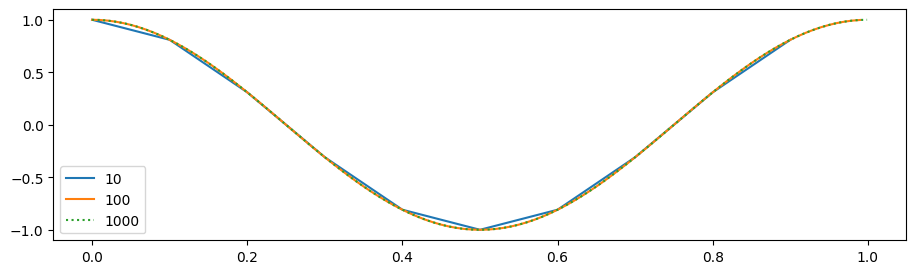

In [5]:
plt.figure(figsize=(11,3))

plt.plot(xx1, yy1, label = "10")
plt.plot(xx2, yy2, label = "100")
plt.plot(xx3, yy3, linestyle= ":",  label = "1000")

plt.legend()
plt.show()

### Measuring execution time

%timeit:

https://docs.python.org/3/library/timeit.html

In [6]:
%timeit DFT_function(yy1) # for sampling rate 1 - sr1 = 10
%timeit DFT_function(yy2) # for sampling rate 2 - sr2 = 100
%timeit DFT_function(yy3) # for sampling rate 3 - sr3 = 1000

The slowest run took 4.59 times longer than the fastest. This could mean that an intermediate result is being cached.
56.8 µs ± 31.7 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
3.04 ms ± 696 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
104 ms ± 18.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## 2. FFT algorithm:




- An FFT rapidly computes such transformations by Matrix decomposition, i.e. the DFT matrix into a product of Sparse matrix (mostly zero) factors. As a result, it manages to reduce the computational complexity of computing the DFT from $O\left(N^2\right)$, which arises if one simply applies the definition of DFT, to $O(N \log N)$, where $N$ is the data size.


If we need to calculate both $X_k$ and $X_{k+N}$, we only need to do this once. This is exactly the idea behind the FFT. Cooley and Tukey showed that we can calculate DFT more efficiently if we continue to divide the problem into smaller ones. Let's first divide the whole series into two parts, i.e. the even number part and the odd number part:

\begin{eqnarray*}
X_{k} &=& \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{kn/N}}} \\
      &=& \sum_{m=0}^{N/2-1}{x_{2m}\cdot e^{-i2\pi{k(2m)/N}}} + \sum_{m=0}^{N/2-1}{x_{2m+1}\cdot e^{-i2\pi{k(2m+1)/N}}} \\
      &=& \sum_{m=0}^{N/2-1}{x_{2m}\cdot e^{-i2\pi{km/(N/2)}}} + e^{-i2\pi{k/N}}\sum_{m=0}^{N/2-1}{x_{2m+1}\cdot e^{-i2\pi{km/(N/2)}}}
\end{eqnarray*}

The two smaller terms which only have half of the size ($\frac{N}{2}$) in the above equation are two smaller DFTs. For each term, the $ 0\leq m \le \frac{N}{2}$, but $ 0\leq k \le N$, therefore, we can see that half of the values will be the same due to the symmetry properties we described above. Thus, we only need to calculate half of the fields in each term. Of course, we don't need to stop here, we can continue to divide each term into half with the even and odd values until it reaches the last two numbers, then calculation will be really simple.

This is how FFT works using this recursive approach.


- The difference in speed can be enormous, especially for long data sets where ''N'' may be in the thousands or millions. In the presence of round-off error, many FFT algorithms are much more accurate than evaluating the DFT definition directly or indirectly.

#### This is for understading the FFT implementation:

In [7]:
# Generate even and odd series

x = np.array([0, 1, 2, 3, 4, 5, 6, 7])

x_even = x[::2]
print(x_even)

x_odd = x[1::2]
print(x_odd)

[0 2 4 6]
[1 3 5 7]


In [8]:
# Concatanate:

a = np.array([[1, 2],[3, 4]])

b = np.array([[5, 6],[7, 8]])

print(a)
print(b)

[[1 2]
 [3 4]]
[[5 6]
 [7 8]]


In [9]:
c1 = np.concatenate([a, b], axis= 1)

c2 = np.concatenate([a, b], axis= 0)

c3 = np.concatenate([a, b])

print(c1)
print("")
print(c2)
print("")
print(c3)

[[1 2 5 6]
 [3 4 7 8]]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]

[[1 2]
 [3 4]
 [5 6]
 [7 8]]


\begin{eqnarray*}
X_{k} &=& \sum_{n=0}^{N-1}{x_n\cdot e^{-i2\pi{kn/N}}} \\
      &=& \sum_{m=0}^{N/2-1}{x_{2m}\cdot e^{-i2\pi{k(2m)/N}}} + \sum_{m=0}^{N/2-1}{x_{2m+1}\cdot e^{-i2\pi{k(2m+1)/N}}} \\
      &=& \sum_{m=0}^{N/2-1}{x_{2m}\cdot e^{-i2\pi{km/(N/2)}}} + e^{-i2\pi{k/N}}\sum_{m=0}^{N/2-1}{x_{2m+1}\cdot e^{-i2\pi{km/(N/2)}}}
\end{eqnarray*}

In [10]:
def FFT_function(signal):

    N = len(signal)

    if N == 1:
        return signal

    else:

        X_even = FFT_function(signal[::2])

        X_odd  = FFT_function(signal[1::2])

        k = np.arange(N)
        e_factor = np.exp(-2j*np.pi*k / N)

        X_k = np.concatenate([X_even + e_factor[:int(N/2)]*X_odd, X_even + e_factor[int(N/2):]*X_odd])

        return X_k


## Example:

(a) Generate 3 sine waves with frequencies $1\rm Hz$, $5 Hz$, and $8 Hz$, amplitudes $4$, $2$ and $0.25$, and phase all zeros.

(b) Plot this $3$ sine waves together with a sampling rate $128 Hz$.

(c) Calculate the DFT and the FFT of the resulting signal and return the DFT values.

In [11]:
def sine_wave(amp, freq, t):
    # amp  = amplitude
    # freq = frequency
    # t    = time_axis

    return amp*np.sin(2*np.pi*freq*t)

In [12]:
# sampling rate
s_rate = 128 #Hz

# sampling interval
a = 0.0
b = 1.0
s_interval = (b - a)/s_rate

# t_axis
t = np.arange(a, b, s_interval)

# y axis
signal_3 = sine_wave(4,1,t) + sine_wave(2,5,t) + sine_wave(0.25,8,t)

### Plotting:


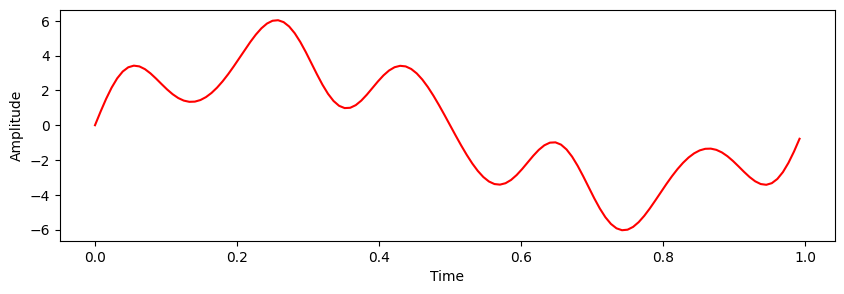

In [13]:
plt.figure(figsize = (10, 3))
plt.plot(t, signal_3, 'r')
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.show()

### Fourier:

In [14]:
fourier_s3 = FFT_function(signal_3)

#print(fourier_s3)

### Calculating frequencies:


In [15]:
# calculate the frequency
N3 = len(fourier_s3)
n3 = np.arange(N3)
T3 = N3/s_rate
freq3 = n3/T3

### Fourier plot:

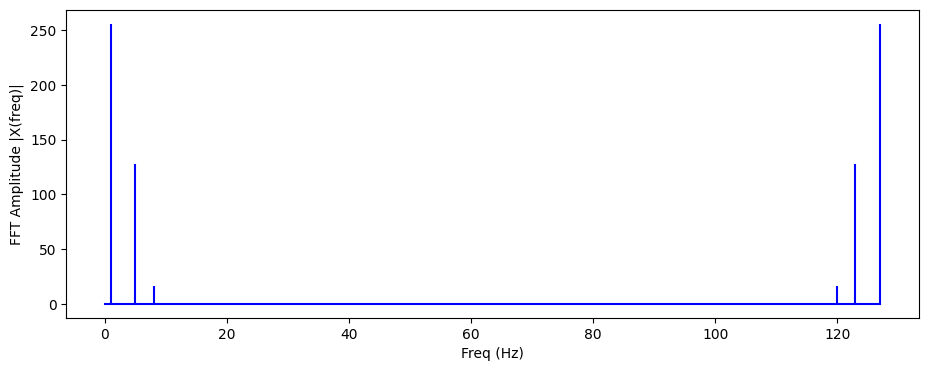

In [16]:
plt.figure(figsize = (11, 4))
plt.stem(freq3, abs(fourier_s3), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

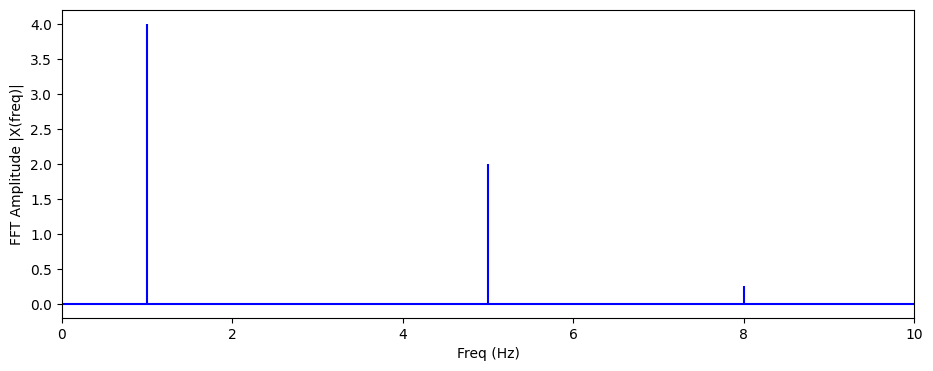

In [17]:
plt.figure(figsize = (11, 4))
plt.stem(freq3[:N3//2], abs(fourier_s3)[:N3//2]/(N3//2), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')

plt.xlim(0,10)
plt.show()

### IMPORTANT: Normalisation -> correct amplitudes

In [18]:
A = abs(fourier_s3)[:N3//2]/(N3//2)

In [19]:
A[:]

array([5.76565970e-17, 4.00000000e+00, 2.14139721e-16, 1.81304952e-16,
       1.79569918e-16, 2.00000000e+00, 3.44623518e-16, 2.00615710e-16,
       2.50000000e-01, 9.89728354e-17, 1.72334249e-16, 2.21328836e-16,
       3.63465946e-16, 1.07713564e-16, 1.75692598e-16, 5.47597190e-16,
       5.73313210e-17, 8.70962959e-17, 1.76805674e-16, 9.21812067e-17,
       3.10364615e-16, 1.75988625e-16, 3.02024831e-17, 1.99892755e-16,
       1.93019880e-16, 3.52047136e-16, 2.79715136e-16, 1.50215270e-16,
       3.82556823e-16, 3.93300758e-16, 4.32123918e-16, 5.19340533e-16,
       1.71386972e-16, 2.42106026e-16, 2.60681337e-16, 4.15677703e-17,
       2.55351395e-16, 5.96724507e-17, 3.81753785e-16, 6.16283923e-16,
       3.53925284e-16, 1.94049083e-16, 7.68645383e-17, 9.54854587e-17,
       1.04445525e-16, 6.93413691e-17, 2.74361696e-16, 2.83890043e-16,
       3.32847417e-16, 1.46609041e-16, 2.70377590e-16, 1.65970294e-16,
       6.25087960e-17, 6.46404090e-17, 2.71856828e-16, 2.93792347e-16,
      

## Comparisons between DFT and FFT:

We go back to the initial problem wwith a cosine function with different sampling rates:

In [20]:
N = 10
print("N = ", N, "N^2 = ", N**2, "Nlog_2(N)= ", N*np.log2(N), "ratio = ", N**2/(N*np.log2(N)))

N = 100
print("N = ", N, "N^2 = ", N**2, "Nlog_2(N)= ", N*np.log2(N), "ratio = ", N**2/(N*np.log2(N)))

N = 10**4
print("N = ", N, "N^2 = ", N**2, "Nlog_2(N)= ", N*np.log2(N), "ratio = ", N**2/(N*np.log2(N)))

N = 10**8
print("N = ", N, "N^2 = ", N**2, "Nlog_2(N)= ", N*np.log2(N), "ratio = ", N**2/(N*np.log2(N)))

N =  10 N^2 =  100 Nlog_2(N)=  33.219280948873624 ratio =  3.0102999566398116
N =  100 N^2 =  10000 Nlog_2(N)=  664.3856189774724 ratio =  15.051499783199061
N =  10000 N^2 =  100000000 Nlog_2(N)=  132877.1237954945 ratio =  752.574989159953
N =  100000000 N^2 =  10000000000000000 Nlog_2(N)=  2657542475.9098897 ratio =  3762874.945799765


In [21]:
def cos_function(sampling_rate):

    t_sampling = 1.0/sampling_rate
    t = np.arange(0,1,t_sampling)

    freq = 1.
    signal = np.cos(2*np.pi*freq*t)

    return signal

In [22]:
sr4 = 4096

In [23]:
%timeit DFT_function(cos_function(sr4)) # for sampling rate 4 - sr4 = 2048
%timeit FFT_function(cos_function(sr4)) # for sampling rate 4 - sr4 = 2048

1.1 s ± 211 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
54.8 ms ± 1.13 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [24]:
DFT_time = sr4**2
FFT_time = sr4*np.log2(sr4)

ratio = DFT_time/FFT_time

print(ratio, 260/16.4)

341.3333333333333 15.853658536585368


### Inverse Fourier transform

In [25]:
signal_invF = np.fft.ifft(fourier_s3)

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


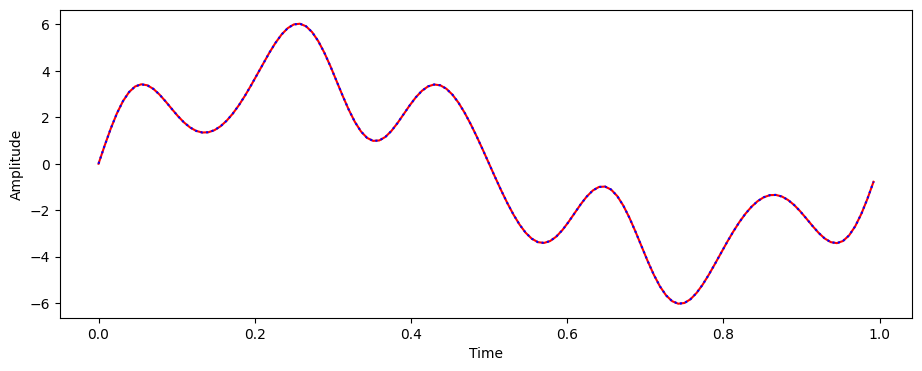

In [26]:
plt.figure(figsize = (11, 4))
plt.plot(t, signal_invF, 'r')
plt.plot(t, signal_3, 'b', linestyle = ':')
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.show()